<a href="https://colab.research.google.com/github/valeriesutanta/pcol3911/blob/main/NB4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load data
data = pd.read_csv("https://raw.githubusercontent.com/valeriesutanta/pcol3911/refs/heads/main/organophosphate_fp.csv")
X = data.iloc[:, :1024]
y = data['Expr'].values

# Same split as your previous notebooks
xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.15, random_state=42)

In [2]:
# ── STEP 1: Define and train all three models ──────────────────────────────

# Random Forest (tuned - your best params from Notebook 3)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(xtrain, ytrain)

# Gradient Boosting Regressor
gbr = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbr.fit(xtrain, ytrain)

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(xtrain, ytrain)

Ridge()

In [3]:
# ── STEP 2: Evaluation function ────────────────────────────────────────────

def evaluate_model(model, X_tr, y_tr, X_te, y_te, name):
    pred_train = model.predict(X_tr)
    pred_test  = model.predict(X_te)

    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  TRAIN  R²:   {r2_score(y_tr, pred_train):.4f}")
    print(f"  TEST   R²:   {r2_score(y_te, pred_test):.4f}")
    print(f"  TEST   MAE:  {mean_absolute_error(y_te, pred_test):.4f}")
    print(f"  TEST   RMSE: {mean_squared_error(y_te, pred_test)**0.5:.4f}")

evaluate_model(rf,    xtrain, ytrain, xtest, ytest, "Random Forest")
evaluate_model(gbr,   xtrain, ytrain, xtest, ytest, "Gradient Boosting")
evaluate_model(ridge, xtrain, ytrain, xtest, ytest, "Ridge Regression")


  Random Forest
  TRAIN  R²:   0.9662
  TEST   R²:   0.7660
  TEST   MAE:  0.5455
  TEST   RMSE: 0.7757

  Gradient Boosting
  TRAIN  R²:   0.9013
  TEST   R²:   0.7438
  TEST   MAE:  0.6047
  TEST   RMSE: 0.8116

  Ridge Regression
  TRAIN  R²:   0.9408
  TEST   R²:   0.7763
  TEST   MAE:  0.4876
  TEST   RMSE: 0.7583


In [4]:
# ── STEP 3: Y-scrambling (permutation test on best model) ──────────────────

n_scrambles = 50
scrambled_r2 = []

for i in range(n_scrambles):
    y_shuffled = ytrain.copy()
    np.random.shuffle(y_shuffled)
    temp_model = RandomForestRegressor(n_estimators=100, random_state=i)
    temp_model.fit(xtrain, y_shuffled)
    scrambled_r2.append(r2_score(ytest, temp_model.predict(xtest)))

real_r2 = r2_score(ytest, rf.predict(xtest))
mean_scrambled = np.mean(scrambled_r2)

print(f"\nReal model R²:          {real_r2:.4f}")
print(f"Mean scrambled R²:      {mean_scrambled:.4f}")
print(f"Model is {'VALID ✓' if real_r2 > mean_scrambled else 'SUSPECT ✗'}")


Real model R²:          0.7660
Mean scrambled R²:      -0.2482
Model is VALID ✓


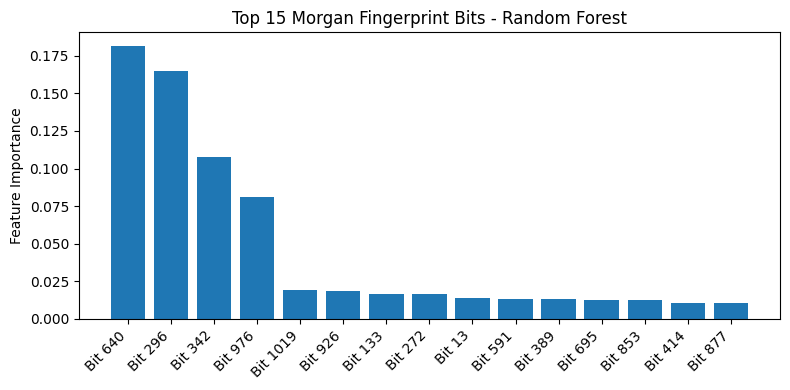


Random Forest - Top 10 bit indices:
[640, 296, 342, 976, 1019, 926, 133, 272, 13, 591]


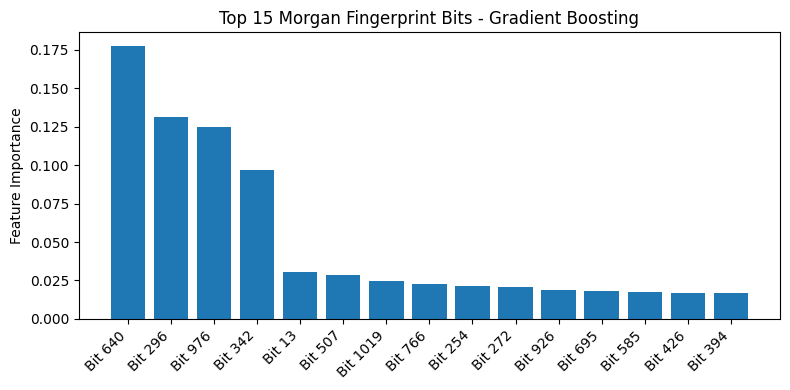


Gradient Boosting - Top 10 bit indices:
[640, 296, 976, 342, 13, 507, 1019, 766, 254, 272]


In [5]:
# ── STEP 4: Feature importance (RF and GBR) ────────────────────────────────

import matplotlib.pyplot as plt

# Get top 15 features for each model
for model, name in [(rf, "Random Forest"), (gbr, "Gradient Boosting")]:
    importances = model.feature_importances_
    top_idx = np.argsort(importances)[-15:][::-1]
    top_vals = importances[top_idx]

    plt.figure(figsize=(8, 4))
    plt.bar(range(15), top_vals)
    plt.xticks(range(15), [f"Bit {i}" for i in top_idx], rotation=45, ha='right')
    plt.title(f"Top 15 Morgan Fingerprint Bits - {name}")
    plt.ylabel("Feature Importance")
    plt.tight_layout()
    plt.show()

    print(f"\n{name} - Top 10 bit indices:")
    print(top_idx[:10].tolist())